In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
plt.figure(figsize=(8, 8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

In [2]:
def sort_contours(cnts, method="left-to-right"):
    reverse = False
    i = 0

    if method == "right-to-left" or method == "bottom-to-top":
        reverse = True

    if method == "top-to-bottom" or method == "bottom-to-top":
        i = 1
    boundingBoxes = [cv2.boundingRect(c) for c in cnts] #用一个最小的矩形，把找到的形状包起来x,y,h,w
    (cnts, boundingBoxes) = zip(*sorted(zip(cnts, boundingBoxes),
                                        key=lambda b: b[1][i], reverse=reverse))

    return cnts, boundingBoxes
def resize(image, width=None, height=None, inter=cv2.INTER_AREA):
    dim = None
    (h, w) = image.shape[:2]
    if width is None and height is None:
        return image
    if width is None:
        r = height / float(h)
        dim = (int(w * r), height)
    else:
        r = width / float(w)
        dim = (width, int(h * r))
    resized = cv2.resize(image, dim, interpolation=inter)
    return resized

## 信用卡号码识别

Credit Card Type: MasterCard
Credit Card #: 5476767898765432


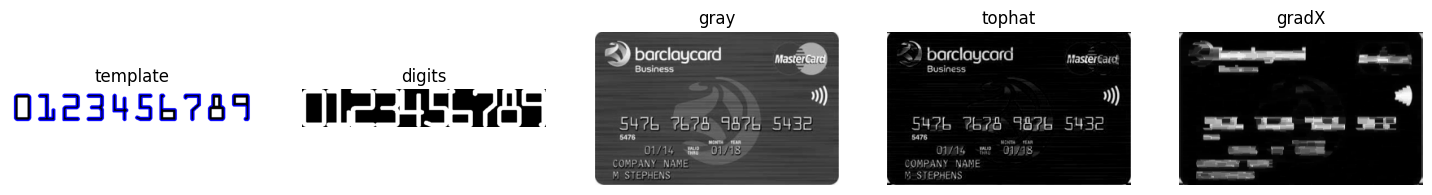

(<Axes: title={'center': 'cur_img'}>,
 Text(0.5, 1.0, 'cur_img'),
 (-0.5, 299.5, 188.5, -0.5))

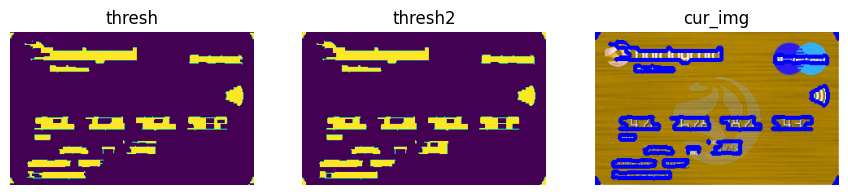

In [6]:
# 指定信用卡类型
FIRST_NUMBER = {
	"3": "American Express",
	"4": "Visa",
	"5": "MasterCard",
	"6": "Discover Card"
}

# 读取一个模板图像
img = cv2.imread('./assets/ocr_a_reference.png')
# 灰度图
ref = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# 二值图像
ref = cv2.threshold(ref, 10, 255, cv2.THRESH_BINARY_INV)[1]

# 计算轮廓
#cv2.findContours()函数接受的参数为二值图，即黑白的（不是灰度图）,cv2.RETR_EXTERNAL只检测外轮廓，cv2.CHAIN_APPROX_SIMPLE只保留终点坐标
#返回的list中每个元素都是图像中的一个轮廓

#ref_, refCnts, hierarchy = cv2.findContours(ref.copy(), cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
refCnts, hierarchy = cv2.findContours(ref.copy(), cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(img,refCnts,-1,(0,0,255),3)

refCnts = sort_contours(refCnts, method="left-to-right")[0]
digits = {}
# 遍历每一个轮廓
for (i, c) in enumerate(refCnts):
	# 计算外接矩形并且resize成合适大小
	(x, y, w, h) = cv2.boundingRect(c)
	roi = ref[y:y + h, x:x + w]
	roi = cv2.resize(roi, (57, 88))

	# 每一个数字对应每一个模板
	digits[i] = roi

# 初始化卷积核
rectKernel = cv2.getStructuringElement(cv2.MORPH_RECT, (9, 3))
sqKernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))

#读取输入图像，预处理
image = cv2.imread('./assets/credit_card_05.png')
image = resize(image, width=300)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 最终，这段代码的目的是在图像上提取边缘信息
#礼帽操作，突出更明亮的区域（原始图像和形态学开运算（先腐蚀后膨胀）之间的差异）
tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, rectKernel) 
# 使用 Sobel 算子计算图像的梯度（x方向上的梯度），ddepth=cv2.CV_32F：指定输出图像的深度为 32 位浮动型数据，这样可以更好地表示梯度值。
gradX = cv2.Sobel(tophat, ddepth=cv2.CV_32F, dx=1, dy=0, #ksize=-1相当于用3*3的
	ksize=-1)
# 取梯度的绝对值，因为梯度值可能是负数（表示沿梯度方向反向的变化）
gradX = np.absolute(gradX)
# 分别计算图像 gradX 中的最小值和最大值，知道梯度图的范围。
(minVal, maxVal) = (np.min(gradX), np.max(gradX))
# 归一化梯度图像到 [0, 255] 的范围
gradX = (255 * ((gradX - minVal) / (maxVal - minVal)))
gradX = gradX.astype("uint8")

#通过闭操作（先膨胀，再腐蚀）将数字连在一起
gradX = cv2.morphologyEx(gradX, cv2.MORPH_CLOSE, rectKernel) 
thresh = cv2.threshold(gradX, 0, 255,
	cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1] 

#再来一个闭操作
thresh2 = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, sqKernel)

# 计算轮廓
threshCnts, hierarchy = cv2.findContours(thresh2.copy(), cv2.RETR_EXTERNAL,
	cv2.CHAIN_APPROX_SIMPLE)

cnts = threshCnts
cur_img = image.copy()
cv2.drawContours(cur_img,cnts,-1,(0,0,255),3) 
locs = []

# 遍历轮廓
for (i, c) in enumerate(cnts):
	# 计算矩形
	(x, y, w, h) = cv2.boundingRect(c)
	ar = w / float(h)

	# 选择合适的区域，根据实际任务来，这里的基本都是四个数字一组
	if ar > 2.5 and ar < 4.0:
		if (w > 40 and w < 55) and (h > 10 and h < 20):
			#符合的留下来
			locs.append((x, y, w, h))
# 将符合的轮廓从左到右排序
locs = sorted(locs, key=lambda x:x[0])
output = []

# 遍历每一个轮廓中的数字
for (i, (gX, gY, gW, gH)) in enumerate(locs):
	# initialize the list of group digits
	groupOutput = []

	# 根据坐标提取每一个组
	group = gray[gY - 5:gY + gH + 5, gX - 5:gX + gW + 5]

	# 预处理
	group = cv2.threshold(group, 0, 255,
		cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
	
	# 计算每一组的轮廓
	digitCnts,hierarchy = cv2.findContours(group.copy(), cv2.RETR_EXTERNAL,
		cv2.CHAIN_APPROX_SIMPLE)
	digitCnts = sort_contours(digitCnts,
		method="left-to-right")[0]

	# 计算每一组中的每一个数值
	for c in digitCnts:
		# 找到当前数值的轮廓，resize成合适的的大小
		(x, y, w, h) = cv2.boundingRect(c)
		roi = group[y:y + h, x:x + w]
		roi = cv2.resize(roi, (57, 88))

		# 计算匹配得分
		scores = []

		# 在模板中计算每一个得分
		for (digit, digitROI) in digits.items():
			# 模板匹配
			result = cv2.matchTemplate(roi, digitROI,
				cv2.TM_CCOEFF)
			(_, score, _, _) = cv2.minMaxLoc(result)
			scores.append(score)

		# 得到最合适的数字
		groupOutput.append(str(np.argmax(scores)))

	# 画出来
	cv2.rectangle(image, (gX - 5, gY - 5),
		(gX + gW + 5, gY + gH + 5), (0, 0, 255), 1)
	cv2.putText(image, "".join(groupOutput), (gX, gY - 15),
		cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 255), 2)

	# 得到结果
	output.extend(groupOutput)

# 打印结果
print("Credit Card Type: {}".format(FIRST_NUMBER[output[0]]))
print("Credit Card #: {}".format("".join(output)))

plt.figure(figsize=(22, 22))
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(12, 12))
res_clahe = clahe.apply(digits[0])
digits_img = np.hstack((digits[0], digits[1], digits[2], digits[3], digits[4], digits[5], digits[6], digits[7], digits[8], digits[9]))

plt.subplot(261), plt.imshow(img), plt.title("template"), plt.axis('off')
plt.subplot(262), plt.imshow(digits_img, 'gray'), plt.title("digits"), plt.axis('off')
plt.subplot(263), plt.imshow(gray, 'gray'), plt.title("gray"), plt.axis('off')
plt.subplot(264), plt.imshow(tophat, 'gray'), plt.title("tophat"), plt.axis('off')
plt.subplot(265), plt.imshow(gradX, 'gray'), plt.title("gradX"), plt.axis('off')
plt.show()
plt.figure(figsize=(22, 22))
plt.subplot(261), plt.imshow(thresh), plt.title("thresh"), plt.axis('off')
plt.subplot(262), plt.imshow(thresh2), plt.title("thresh2"), plt.axis('off')
plt.subplot(263), plt.imshow(cur_img), plt.title("cur_img"), plt.axis('off')

